In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
import os
import sys
import subprocess

try:
    import pywt
except:
    subprocess.check_call([sys.executable,"-m","pip","install","-q","PyWavelets"])
    import pywt

os.makedirs("lab6",exist_ok=True)

links={
"box.png":"https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png",
"box_scene.png":"https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png",
"building.jpg":"https://raw.githubusercontent.com/opencv/opencv/master/samples/data/building.jpg",
"road.jpg":"https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidWhiteRight.jpg"
}

for name,url in links.items():
    if not os.path.exists("lab6/"+name):
        urlretrieve(url,"lab6/"+name)

In [ ]:
# Task 1

img=np.full((520,900,3),220,np.uint8)

for r in range(2):
    for c in range(4):
        x=70+c*205
        y=70+r*230
        cv2.rectangle(img,(x,y),(x+150,y+105),(30,30,30),5)
        value=20 if (r+c)%3 else 150
        cv2.rectangle(img,(x+8,y+8),(x+142,y+97),(value,value,value),-1)
        cv2.line(img,(x+75,y+105),(x+75,y+135),(40,40,40),5)
        cv2.line(img,(x+45,y+135),(x+105,y+135),(40,40,40),5)

gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges=cv2.Canny(gray,50,150)

lines=cv2.HoughLinesP(edges,1,np.pi/180,60,minLineLength=70,maxLineGap=10)

result=img.copy()

if lines is not None:
    for line in lines:
        x1,y1,x2,y2=line[0]
        cv2.line(result,(x1,y1),(x2,y2),(0,255,0),2)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

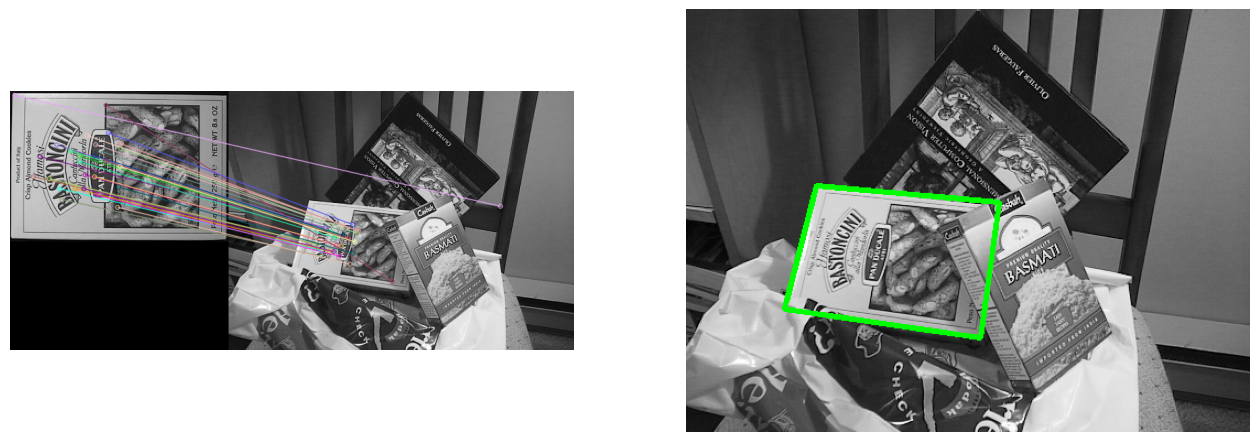

In [2]:
# Task 2

ref=cv2.imread("lab6/box.png",0)
scene=cv2.imread("lab6/box_scene.png",0)

sift=cv2.SIFT_create()
kp1,des1=sift.detectAndCompute(ref,None)
kp2,des2=sift.detectAndCompute(scene,None)

matcher=cv2.BFMatcher()
pairs=matcher.knnMatch(des1,des2,k=2)
good=[m for m,n in pairs if m.distance<0.72*n.distance]

out=cv2.cvtColor(scene,cv2.COLOR_GRAY2BGR)

if len(good)>=4:
    src=np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst=np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    H,_=cv2.findHomography(src,dst,cv2.RANSAC,5)

    h,w=ref.shape
    corners=np.float32([[0,0],[w,0],[w,h],[0,h]]).reshape(-1,1,2)
    box=cv2.perspectiveTransform(corners,H)
    cv2.polylines(out,[np.int32(box)],True,(0,255,0),3)

matches=cv2.drawMatches(ref,kp1,scene,kp2,good[:30],None,
                        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.imshow(matches,cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

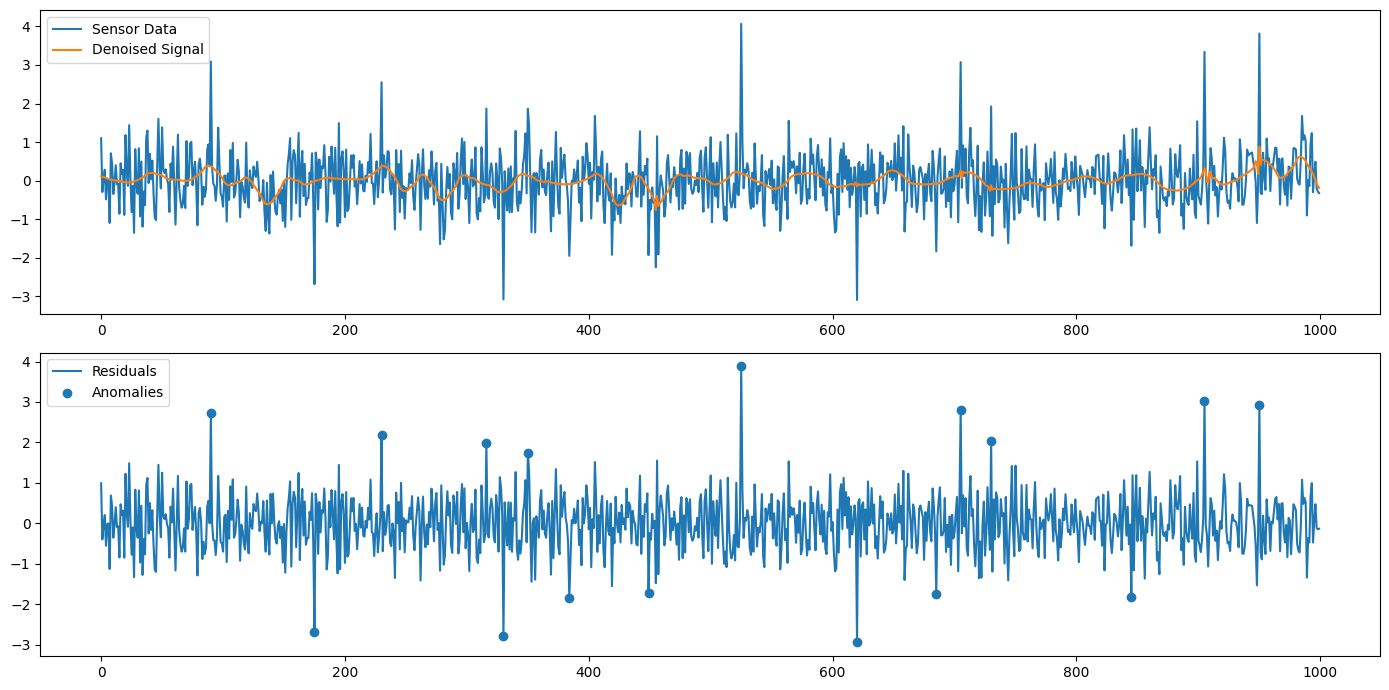

In [3]:
# Task 3

np.random.seed(7)

n=1000
x=np.arange(n)
signal=0.15*np.sin(x/25)+np.random.normal(0,0.65,n)

spots=[90,175,230,330,405,455,525,620,705,730,845,905,950]
signal[spots]+=np.array([2.8,-2.7,2.6,-3,2.8,-2.6,3,-3,2.7,2.9,-2.8,3,2.6])

wave="db4"
coeff=pywt.wavedec(signal,wave,level=4)

sigma=np.median(np.abs(coeff[-1]))/0.6745
limit=sigma*np.sqrt(2*np.log(n))

clean=[coeff[0]]
for c in coeff[1:]:
    clean.append(pywt.threshold(c,limit,mode="soft"))

denoised=pywt.waverec(clean,wave)[:n]
residual=signal-denoised

cut=np.mean(np.abs(residual))+2.5*np.std(np.abs(residual))
anomaly=np.where(np.abs(residual)>cut)[0]

plt.figure(figsize=(14,7))

plt.subplot(2,1,1)
plt.plot(signal,label="Sensor Data")
plt.plot(denoised,label="Denoised Signal")
plt.legend()

plt.subplot(2,1,2)
plt.plot(residual)
plt.scatter(anomaly,residual[anomaly])
plt.legend(["Residuals","Anomalies"])

plt.tight_layout()
plt.show()

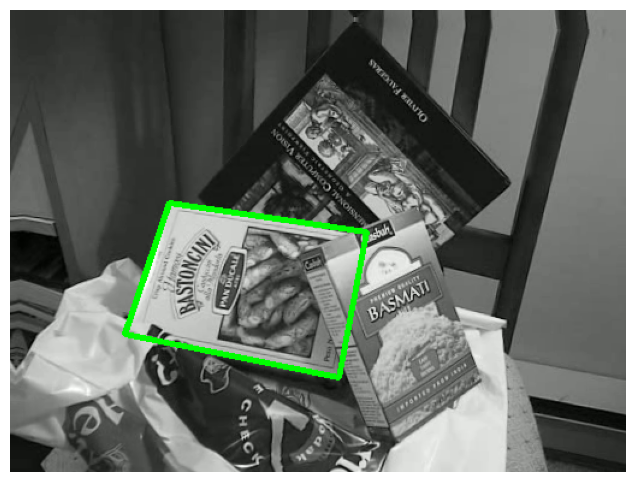

In [4]:
# Task 4

ref=cv2.imread("lab6/box.png",0)
scene=cv2.imread("lab6/box_scene.png")

h,w=scene.shape[:2]
video=cv2.VideoWriter("lab6/object_video.mp4",cv2.VideoWriter_fourcc(*"mp4v"),10,(w,h))

for i in range(40):
    angle=np.sin(i/7)*5
    dx=int(np.sin(i/5)*12)
    dy=int(np.cos(i/6)*8)
    M=cv2.getRotationMatrix2D((w//2,h//2),angle,1)
    M[:,2]+=[dx,dy]
    frame=cv2.warpAffine(scene,M,(w,h),borderMode=cv2.BORDER_REFLECT)
    video.write(frame)

video.release()

sift=cv2.SIFT_create()
kp1,des1=sift.detectAndCompute(ref,None)
matcher=cv2.BFMatcher()

cap=cv2.VideoCapture("lab6/object_video.mp4")
writer=cv2.VideoWriter("lab6/object_detected.mp4",cv2.VideoWriter_fourcc(*"mp4v"),10,(w,h))
last=None

while True:
    ok,frame=cap.read()

    if not ok:
        break

    gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    kp2,des2=sift.detectAndCompute(gray,None)

    if des2 is not None:
        pairs=matcher.knnMatch(des1,des2,k=2)
        good=[m for m,n in pairs if m.distance<0.72*n.distance]

        if len(good)>=8:
            src=np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
            dst=np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
            H,_=cv2.findHomography(src,dst,cv2.RANSAC,5)

            if H is not None:
                rh,rw=ref.shape
                corners=np.float32([[0,0],[rw,0],[rw,rh],[0,rh]]).reshape(-1,1,2)
                box=cv2.perspectiveTransform(corners,H)
                cv2.polylines(frame,[np.int32(box)],True,(0,255,0),3)

    writer.write(frame)
    last=frame.copy()

cap.release()
writer.release()

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(last,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

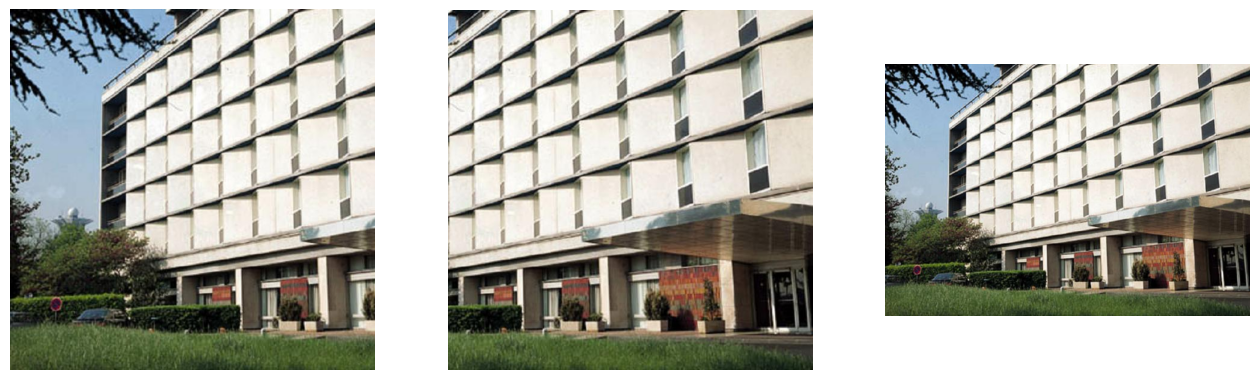

True

In [5]:
# Task 5

img=cv2.imread("lab6/building.jpg")
h,w=img.shape[:2]

left=img[:,0:int(w*0.7)]
right=img[:,int(w*0.3):w]

gray1=cv2.cvtColor(left,cv2.COLOR_BGR2GRAY)
gray2=cv2.cvtColor(right,cv2.COLOR_BGR2GRAY)

sift=cv2.SIFT_create()
kp1,d1=sift.detectAndCompute(gray1,None)
kp2,d2=sift.detectAndCompute(gray2,None)

matcher=cv2.BFMatcher()
pairs=matcher.knnMatch(d2,d1,k=2)
good=[m for m,n in pairs if m.distance<0.72*n.distance]

src=np.float32([kp2[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst=np.float32([kp1[m.trainIdx].pt for m in good]).reshape(-1,1,2)

H,_=cv2.findHomography(src,dst,cv2.RANSAC,5)

h1,w1=left.shape[:2]
h2,w2=right.shape[:2]

c1=np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2)
c2=np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)
c2=cv2.perspectiveTransform(c2,H)

pts=np.concatenate((c1,c2),axis=0)
xmin,ymin=np.floor(pts.min(axis=0).ravel()).astype(int)
xmax,ymax=np.ceil(pts.max(axis=0).ravel()).astype(int)

T=np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]],dtype=np.float64)

pano=cv2.warpPerspective(right,T@H,(xmax-xmin,ymax-ymin))
pano[-ymin:h1-ymin,-xmin:w1-xmin]=left

mask=cv2.cvtColor(pano,cv2.COLOR_BGR2GRAY)>0
ys,xs=np.where(mask)
pano=pano[ys.min():ys.max()+1,xs.min():xs.max()+1]

plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(left,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(right,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(pano,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

cv2.imwrite("lab6/panorama.jpg",pano)

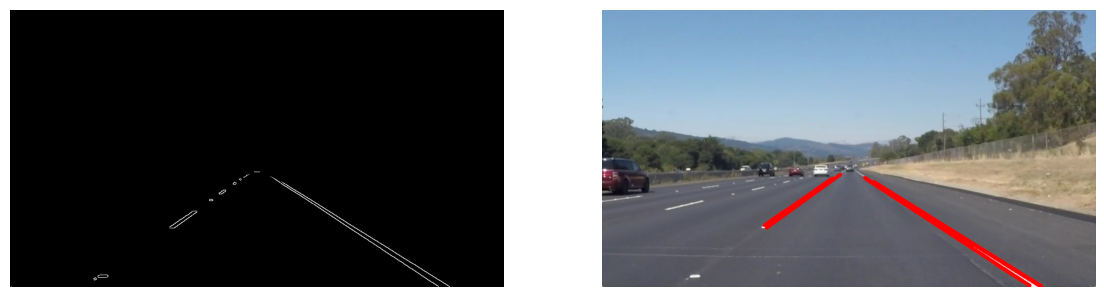

In [6]:
# Task 6

img=cv2.imread("lab6/road.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
blur=cv2.GaussianBlur(gray,(5,5),0)
edges=cv2.Canny(blur,50,150)

h,w=edges.shape
mask=np.zeros_like(edges)
roi=np.array([[(0,h),(w//2,int(h*0.58)),(w,h)]],np.int32)
cv2.fillPoly(mask,roi,255)

road_edges=cv2.bitwise_and(edges,mask)

lines=cv2.HoughLinesP(road_edges,1,np.pi/180,25,minLineLength=35,maxLineGap=90)

result=img.copy()

if lines is not None:
    for line in lines:
        x1,y1,x2,y2=line[0]
        slope=(y2-y1)/(x2-x1+1e-6)

        if abs(slope)>0.35:
            cv2.line(result,(x1,y1),(x2,y2),(0,0,255),5)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(road_edges,cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Coins: 14


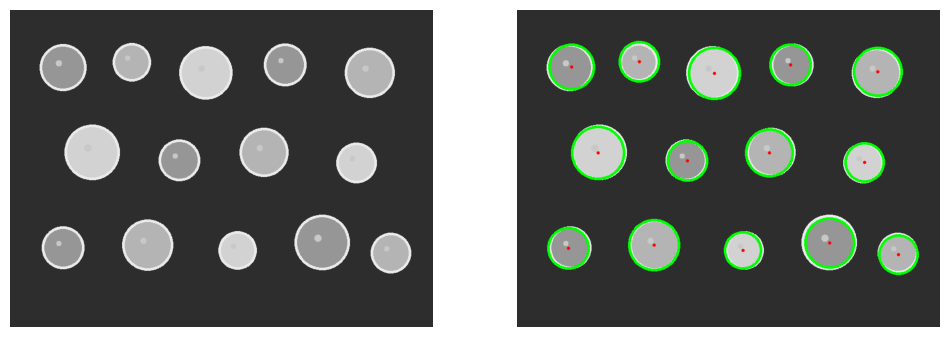

In [7]:
# Task 7

img=np.full((600,800,3),45,np.uint8)

coins=[
(100,110,42),(230,100,34),(370,120,48),(520,105,38),(680,120,45),
(155,270,50),(320,285,37),(480,270,44),(655,290,36),
(100,450,38),(260,445,46),(430,455,34),(590,440,50),(720,460,36)
]

for i,(x,y,r) in enumerate(coins):
    shade=150+(i%3)*30
    cv2.circle(img,(x,y),r,(shade,shade,shade),-1)
    cv2.circle(img,(x,y),r,(235,235,235),3)
    cv2.circle(img,(x-8,y-8),max(5,r//7),(200,200,200),-1)

gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray=cv2.medianBlur(gray,5)

circles=cv2.HoughCircles(gray,cv2.HOUGH_GRADIENT,1.2,60,
                         param1=100,param2=35,minRadius=25,maxRadius=55)

result=img.copy()
count=0

if circles is not None:
    circles=np.uint16(np.around(circles[0]))
    count=len(circles)

    for x,y,r in circles:
        cv2.circle(result,(x,y),r,(0,255,0),3)
        cv2.circle(result,(x,y),3,(0,0,255),-1)

print("Coins:",count)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

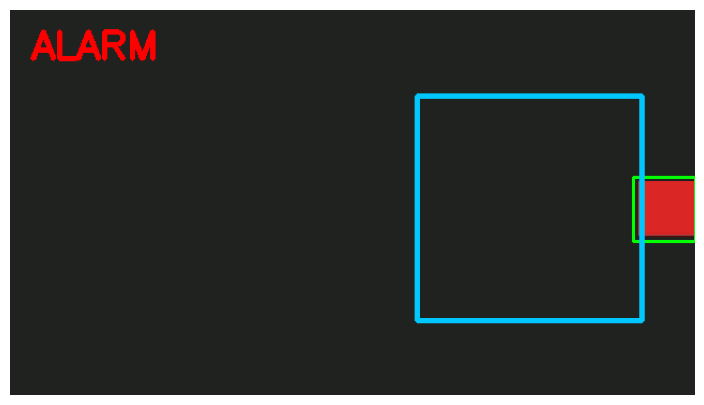

In [8]:
# Task 8

w,h=640,360
background=np.full((h,w,3),35,np.uint8)

zone=(380,80,210,210)

writer=cv2.VideoWriter("lab6/security_input.mp4",cv2.VideoWriter_fourcc(*"mp4v"),15,(w,h))

for i in range(75):
    frame=background.copy()
    x=-70+i*9
    y=160
    cv2.rectangle(frame,(x,y),(x+65,y+50),(40,40,220),-1)
    writer.write(frame)

writer.release()

cap=cv2.VideoCapture("lab6/security_input.mp4")
out=cv2.VideoWriter("lab6/security_output.mp4",cv2.VideoWriter_fourcc(*"mp4v"),15,(w,h))

sample=None

while True:
    ok,frame=cap.read()

    if not ok:
        break

    diff=cv2.absdiff(frame,background)
    gray=cv2.cvtColor(diff,cv2.COLOR_BGR2GRAY)
    _,th=cv2.threshold(gray,35,255,cv2.THRESH_BINARY)
    th=cv2.morphologyEx(th,cv2.MORPH_OPEN,np.ones((5,5),np.uint8))
    th=cv2.dilate(th,np.ones((5,5),np.uint8),iterations=2)

    contours,_=cv2.findContours(th,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    zx,zy,zw,zh=zone
    alarm=False

    for cnt in contours:
        if cv2.contourArea(cnt)<500:
            continue

        x,y,bw,bh=cv2.boundingRect(cnt)
        cv2.rectangle(frame,(x,y),(x+bw,y+bh),(0,255,0),2)

        overlap=x<zx+zw and x+bw>zx and y<zy+zh and y+bh>zy

        if overlap:
            alarm=True

    cv2.rectangle(frame,(zx,zy),(zx+zw,zy+zh),(255,200,0),3)

    if alarm:
        cv2.putText(frame,"ALARM",(20,45),cv2.FONT_HERSHEY_SIMPLEX,1.2,(0,0,255),3)

    out.write(frame)

    if alarm:
        sample=frame.copy()

cap.release()
out.release()

plt.figure(figsize=(9,5))
plt.imshow(cv2.cvtColor(sample,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()